<a href="https://colab.research.google.com/github/sam08coder/HAIR_SECRET.com/blob/main/cat_dog_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

cat and dog dataset import

In [1]:
import kagglehub

path = kagglehub.dataset_download("niryaffe/cats-and-dogs-image-dataset")
print("Path to dataset files:", path)


100%|██████████| 1.76M/1.76M [00:00<00:00, 114MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1


looking into the dataset


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    print(files[:5])

/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1 -> 0 files
[]
/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content -> 0 files
[]
/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content/drive -> 0 files
[]
/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content/drive/MyDrive -> 0 files
[]
/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content/drive/MyDrive/DATA -> 0 files
[]
/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content/drive/MyDrive/DATA/cats and dogs -> 9 files
['cat2.jpg', 'cat1.jpg', 'new_dog1.jpg', 'new_cat1.jpg', 'cats and dogs.csv']


CSV check

In [3]:
import pandas as pd

data_dir = "/root/.cache/kagglehub/datasets/niryaffe/cats-and-dogs-image-dataset/versions/1/content/drive/MyDrive/DATA/cats and dogs"

csv_path = os.path.join(data_dir, "cats and dogs.csv")
df = pd.read_csv(csv_path)
print(df)

print(os.listdir(data_dir))

   filename  label
0  dog1.jpg      1
1  dog2.jpg      1
2  dog3.jpg      1
3  cat1.jpg      0
4  cat2.jpg      0
5  cat3.jpg      0
['cat2.jpg', 'cat1.jpg', 'new_dog1.jpg', 'new_cat1.jpg', 'cats and dogs.csv', 'cat3.jpg', 'dog2.jpg', 'dog3.jpg', 'dog1.jpg']


section 1


In [4]:
# ---- Section 1: Data Preprocessing ----
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split

img_size = (150, 150)

# Load and organize the dataset using the CSV labels
image_paths = [os.path.join(data_dir, fname) for fname in df["filename"]]
labels = df["label"].values

# Load images into arrays, resize to a uniform size, normalize pixel values (0-1)
images = []
for p in image_paths:
    img = load_img(p, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    images.append(img_array)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels:", labels)

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=2, random_state=42, stratify=labels
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Images shape: (6, 150, 150, 3)
Labels: [1 1 1 0 0 0]
Training samples: 4
Validation samples: 2


section 1b

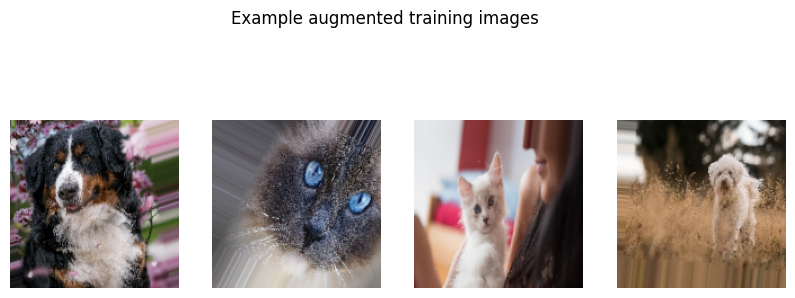

In [5]:
# Augment the training data so the model sees many variations of each image
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=4)

# Preview a few augmented images
plt.figure(figsize=(10,4))
sample_batch = next(train_generator)
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(sample_batch[0][i])
    plt.axis('off')
plt.suptitle("Example augmented training images")
plt.show()

section 2

In [6]:
# ---- Section 2: Model Development ----
from tensorflow.keras import layers, models

model = models.Sequential([
    # Input layer - expects 150x150 RGB images
    layers.Input(shape=(150, 150, 3)),

    # Convolutional and pooling layers - extract visual features
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten before feeding into dense layers
    layers.Flatten(),

    # Fully connected (dense) layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # helps prevent overfitting, important given our tiny dataset

    # Output layer - single neuron, sigmoid gives probability of "dog" (label 1)
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

section 3

In [7]:
# ---- Section 3: Model Training and Validation ----

# Train with appropriate parameters
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

epochs = 20

history = model.fit(
    train_generator,
    steps_per_epoch=2,          # 4 training images / batch_size 4
    validation_data=(X_val, y_val),
    epochs=epochs
)

Epoch 1/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2500 - loss: 0.7199

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 519ms/step - accuracy: 0.2500 - loss: 0.7199 - val_accuracy: 0.5000 - val_loss: 0.7869
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5000 - loss: 0.6446 - val_accuracy: 0.5000 - val_loss: 0.7779
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5000 - loss: 0.8421 - val_accuracy: 0.5000 - val_loss: 0.6906
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.5054 - val_accuracy: 0.5000 - val_loss: 0.7040
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7500 - loss: 0.5536 - val_accuracy: 0.5000 - val_loss: 0.7107
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2500 - loss: 1.0718 - val_accuracy: 0.5000 - val_loss: 0.7383
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7500 - loss: 0.5520 - val_accuracy: 0.5000 - val_loss: 0.8151
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.0000e+00 - loss: 1.2345 - val_accuracy: 0.5000 - val_loss: 0.8657
Epoch

section 4

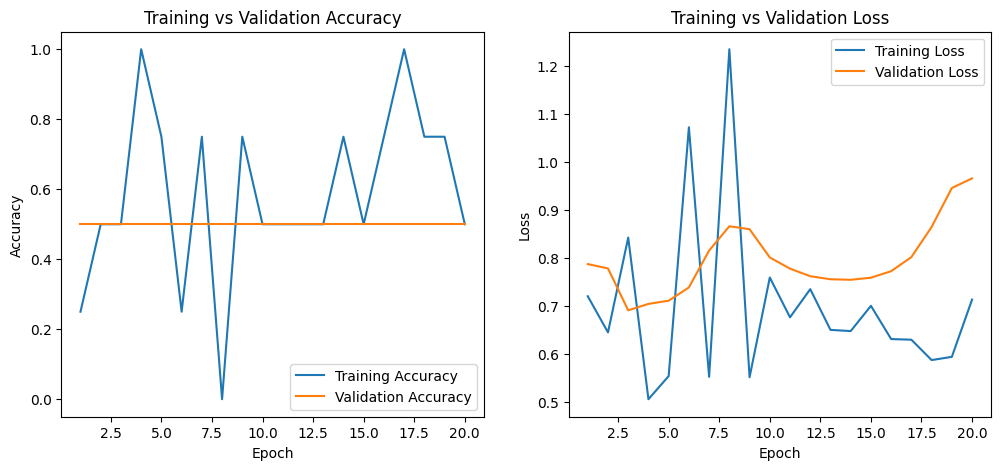

In [8]:
# ---- Section 4a: Accuracy and Loss plots ----
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
True labels:      [1 0]
Predicted labels: [1 1]


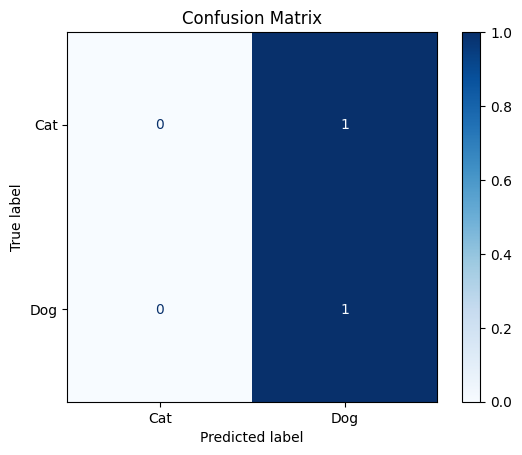

              precision    recall  f1-score   support

         Cat       0.00      0.00      0.00         1
         Dog       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# ---- Section 4b: Confusion Matrix ----
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on validation set
val_preds_prob = model.predict(X_val)
val_preds = (val_preds_prob > 0.5).astype(int).flatten()

print("True labels:     ", y_val)
print("Predicted labels:", val_preds)

cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_val, val_preds, target_names=['Cat', 'Dog']))